# Detecting Counters / Contours

In the code file we call this step `counter_detection.py`. In OpenCV, the usual word is **contour**: a curve around connected edge pixels. For our OMR project, this is useful because the answer sheet has strong rectangular regions that can help us locate the paper and important boxes.

The flow in this notebook is intentionally visual:

1. Start with one sample answer-sheet image.
2. Run the preprocessing functions to create a Canny edge image.
3. Save that Canny image in `samples/` so the contour stage has a clear input.
4. Run each contour-detection function and display what changed.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from preprocessing import (
    resize_image,
    image_to_grayscale,
    add_gaussian_blur,
    apply_canny_edge_detection,
)

from counter_detection import (
    find_all_contours,
    draw_all_contours,
    filter_rectangular_contours,
    get_corner_points,
    reorder_corner_points,
    draw_corner_points,
)

In [2]:
def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))


def show_image(image, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)

    ax.set_title(title)
    ax.axis("off")
    return ax


def show_grid(items, columns=3, figsize=(16, 8)):
    rows = int(np.ceil(len(items) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (title, image) in zip(axes, items):
        show_image(image, title, ax=ax)

    for ax in axes[len(items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def draw_numbered_points(image, points):
    image_copy = image.copy()
    labels = ["top-left", "top-right", "bottom-left", "bottom-right"]

    for index, point in enumerate(points.reshape((4, 2))):
        x, y = int(point[0]), int(point[1])
        cv2.putText(
            image_copy,
            str(index + 1),
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )

    for index, label in enumerate(labels, start=1):
        print(f"{index}: {label}")

    return image_copy

## 1. Choose a Sample Image

We use `File0005.jpg` here because it has a clear answer-sheet border. Later, we can repeat the same notebook with more collected samples.

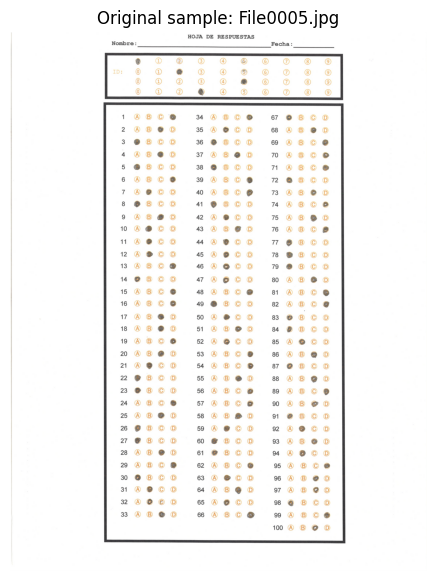

Original shape: (4395, 3396, 3)


In [3]:
source_path = Path("samples/File0005.jpg")

if not source_path.exists():
    raise FileNotFoundError(f"Missing sample image: {source_path}")

original_image = load_rgb(source_path)
show_image(original_image, f"Original sample: {source_path.name}")
plt.show()

print("Original shape:", original_image.shape)

## 2. Run Preprocessing First

Contour detection should not start from the raw RGB image. We first resize, convert to grayscale, blur a little to reduce noise, and then apply Canny edge detection.

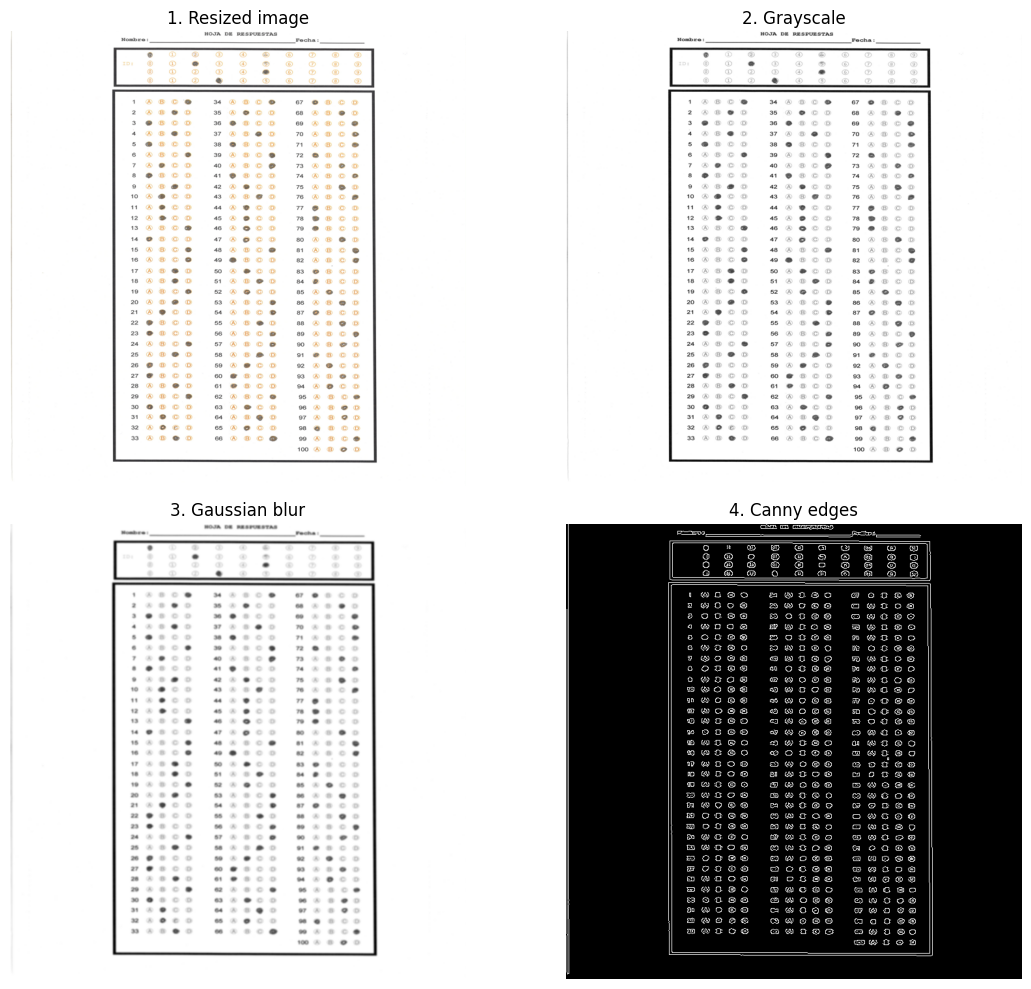

Saved Canny image to: samples/canny_File0005.png


In [4]:
resized_image = resize_image(original_image)
grayscale_image = image_to_grayscale(resized_image)
blurred_image = add_gaussian_blur(grayscale_image)
canny_image = apply_canny_edge_detection(blurred_image)

canny_output_path = Path("samples/canny_File0005.png")
cv2.imwrite(str(canny_output_path), canny_image)

show_grid([
    ("1. Resized image", resized_image),
    ("2. Grayscale", grayscale_image),
    ("3. Gaussian blur", blurred_image),
    ("4. Canny edges", canny_image),
], columns=2, figsize=(12, 10))

print(f"Saved Canny image to: {canny_output_path}")

## 3. `find_all_contours`

This function asks OpenCV to find the outside boundaries in the Canny image. At this stage, we are not judging which contours are useful yet. We just collect them.

Number of external contours found: 11


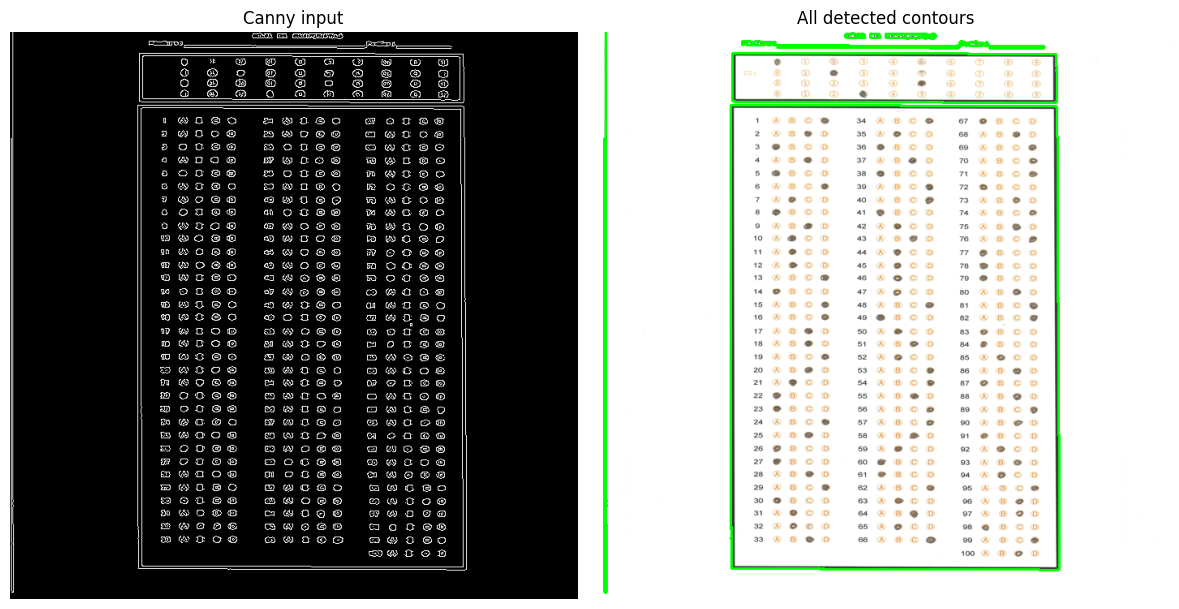

In [5]:
contours = find_all_contours(canny_image)

print("Number of external contours found:", len(contours))

all_contours_image = draw_all_contours(
    resized_image,
    contours,
    color=(0, 255, 0),
    thickness=2,
)

show_grid([
    ("Canny input", canny_image),
    ("All detected contours", all_contours_image),
], columns=2, figsize=(12, 6))

## 4. `filter_rectangular_contours`

Not every contour is useful. For answer sheets, rectangle-like contours matter because they often represent the page border, ID box, answer block, or other structured regions.

Rectangle-like contours kept: 2
Rectangle 1: area = 230641.5
Rectangle 2: area = 24010.5


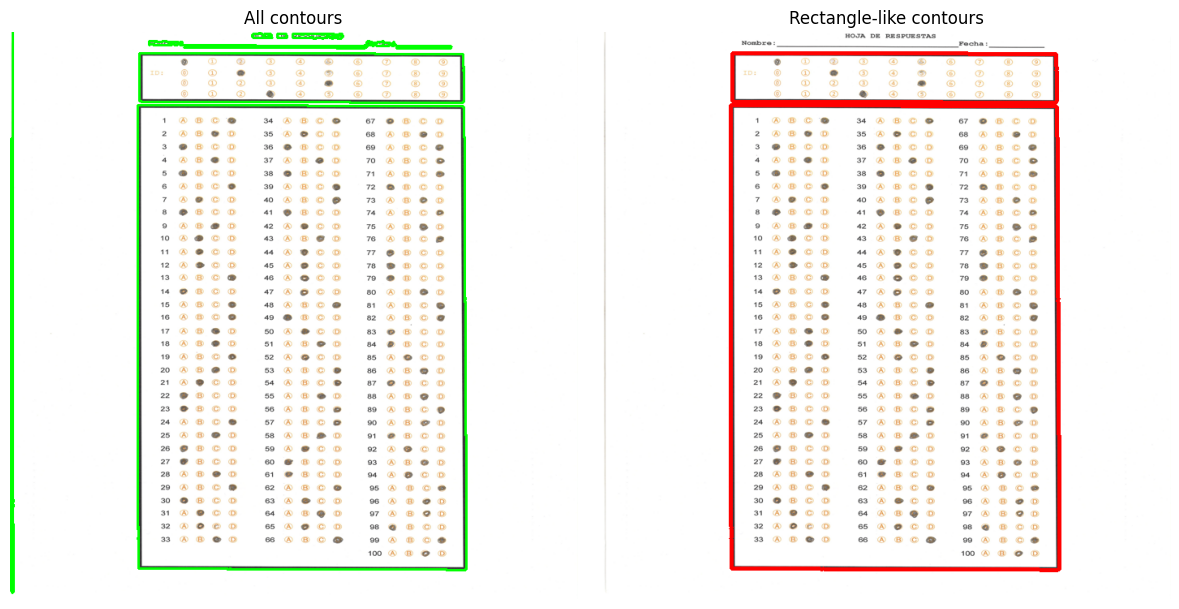

In [6]:
rectangular_contours = filter_rectangular_contours(contours, min_area=1000)

print("Rectangle-like contours kept:", len(rectangular_contours))

for index, contour in enumerate(rectangular_contours[:5], start=1):
    print(f"Rectangle {index}: area = {cv2.contourArea(contour):.1f}")

rectangles_image = draw_all_contours(
    resized_image,
    rectangular_contours,
    color=(255, 0, 0),
    thickness=3,
)

show_grid([
    ("All contours", all_contours_image),
    ("Rectangle-like contours", rectangles_image),
], columns=2, figsize=(12, 6))

## 5. `get_corner_points` and `reorder_corner_points`

For perspective correction later, the four corners need a stable order. The function reorders them as: top-left, top-right, bottom-left, bottom-right.

Raw corner points:
[[157  91]
 [158 662]
 [562 663]
 [559  93]]

Reordered corner points:
[[157  91]
 [559  93]
 [158 662]
 [562 663]]
1: top-left
2: top-right
3: bottom-left
4: bottom-right


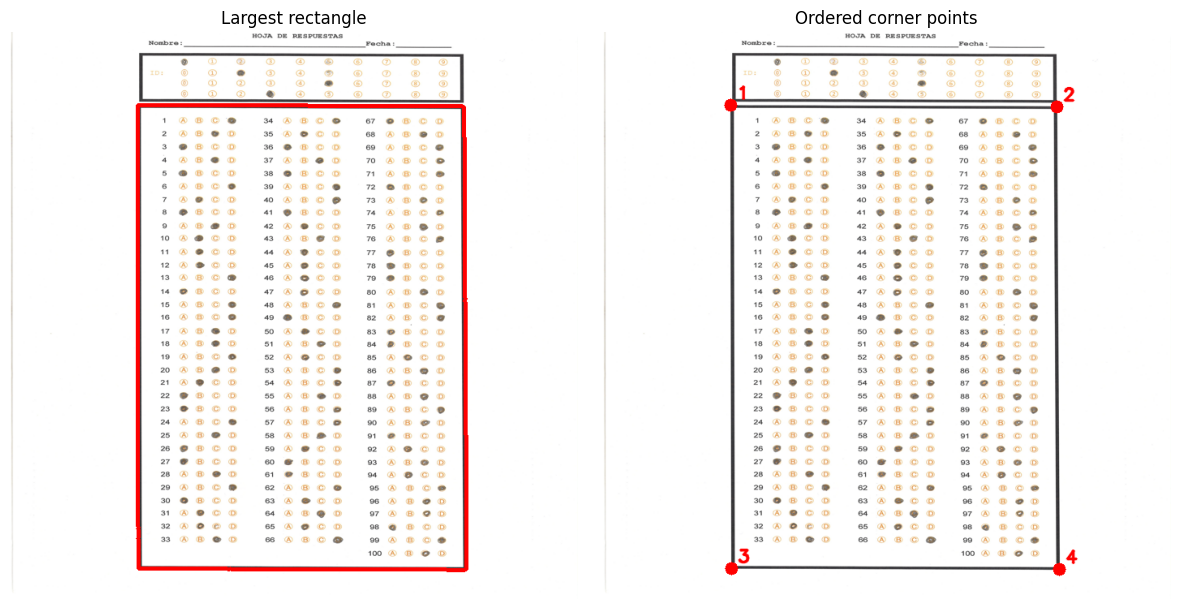

In [7]:
if not rectangular_contours:
    raise RuntimeError("No rectangular contours found. Try lowering min_area or checking the Canny image.")

largest_rectangle = rectangular_contours[0]
corner_points = get_corner_points(largest_rectangle)
reordered_points = reorder_corner_points(corner_points)

print("Raw corner points:")
print(corner_points.reshape((4, 2)))

print("\nReordered corner points:")
print(reordered_points.astype(int))

corner_image = draw_corner_points(
    resized_image,
    reordered_points,
    color=(255, 0, 0),
    radius=8,
)
corner_image = draw_numbered_points(corner_image, reordered_points)

show_grid([
    ("Largest rectangle", draw_all_contours(resized_image, [largest_rectangle], color=(255, 0, 0), thickness=3)),
    ("Ordered corner points", corner_image),
], columns=2, figsize=(12, 6))

## What this gives us

This notebook does not grade the sheet yet. Its job is to prove that the project can move from a raw sample image to edges, contours, rectangle filtering, and ordered corner points. That is a strong foundation for the later OMR steps: perspective correction, answer-region extraction, and bubble/mark detection.